In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

In [2]:
import joblib

model = joblib.load(
    "../models/churn_model.pkl"
)

In [3]:
df = pd.read_csv(
    "../data/processed/cleaned_customer_churn.csv"
)

In [4]:
X = df.drop(
    columns=["customerID", "Churn"]
)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [5]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

C:\Users\Nayana Patel G C\AppData\Local\Temp\ipykernel_18752\1168470759.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [6]:
preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
X_test_processed = preprocessor.transform(
    X_test
)

In [9]:
y_pred = model.predict(
    X_test_processed
)

y_probability = model.predict_proba(
    X_test_processed
)[:, 1]

In [10]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [11]:
evaluation = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_probability)
}

evaluation_df = pd.DataFrame(
    [evaluation]
)

evaluation_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.805536,0.657233,0.558824,0.604046,0.842135


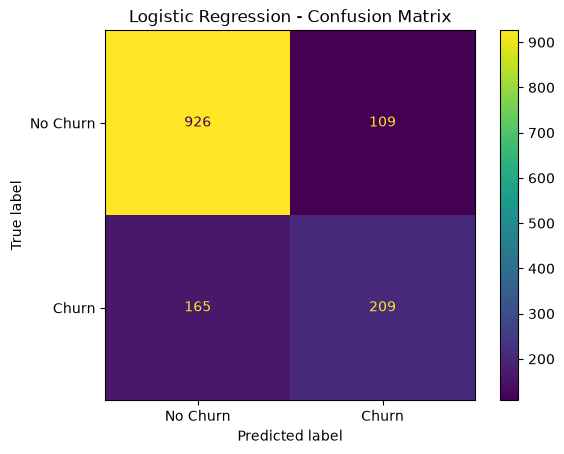

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

disp.plot()

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.show()

In [13]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

roc_auc = auc(
    fpr,
    tpr
)

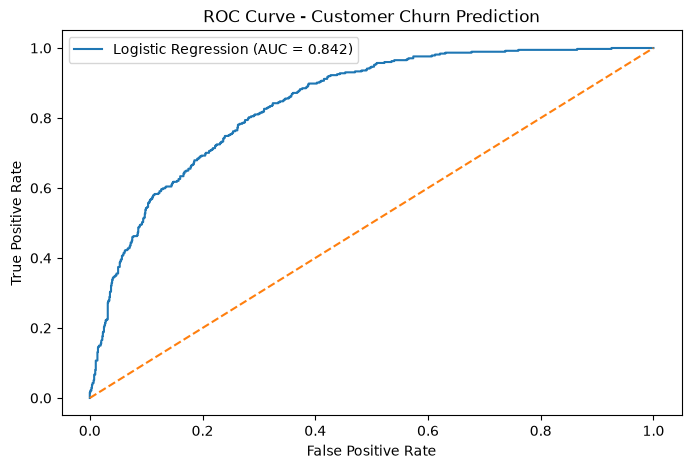

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Customer Churn Prediction")

plt.legend()

plt.show()

In [15]:
CHURN_THRESHOLD = 0.40

threshold_pred = (
    y_probability >= CHURN_THRESHOLD
).astype(int)

In [16]:
threshold_evaluation = {
    "Threshold": CHURN_THRESHOLD,
    "Precision": precision_score(
        y_test,
        threshold_pred
    ),
    "Recall": recall_score(
        y_test,
        threshold_pred
    ),
    "F1 Score": f1_score(
        y_test,
        threshold_pred
    )
}

pd.DataFrame(
    [threshold_evaluation]
)

,Threshold,Precision,Recall,F1 Score
0,0.4,0.568182,0.668449,0.614251


## Final Model Evaluation

Logistic Regression was selected as the baseline/final prediction model
because it achieved strong overall performance with an ROC-AUC of
approximately 84.2%.

At the default 0.50 threshold, the model achieved approximately:

- Accuracy: 80.55%
- Precision: 65.72%
- Recall: 55.88%
- F1 Score: 60.48%
- ROC-AUC: 84.21%

For the customer retention use case, a threshold of 0.40 was selected
to improve churn detection.

At the 0.40 threshold:

- Precision: approximately 56.8%
- Recall: approximately 66.8%
- F1 Score: approximately 61.4%

The lower threshold increases recall, allowing the business to identify
more potentially at-risk customers for retention campaigns.